# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [ ]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.with_row_index("event_index")

data = data.filter(pl.col("reco_ok") == True)

#removed the 1- from inelasticity to check something, will add back in later

data = data.with_columns(
	( (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	( (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))

	

data = data.to_pandas()
data = data.dropna()
data

,event_index,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,4.352918e-01,0.981985,1
1,1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,4.803471e-01,0.310157,1
2,2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,2.649064e-01,0.254924,1
3,4,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,1.766871e-01,0.149645,0
4,5,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,1.108138e-02,0.011092,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,2884698,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,-5.172407e-16,0.000000,0
2651023,2884699,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,1.501929e-02,0.009781,0
2651024,2884700,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,1.129947e-01,0.067633,0
2651025,2884701,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,4.078746e-02,0.913077,0


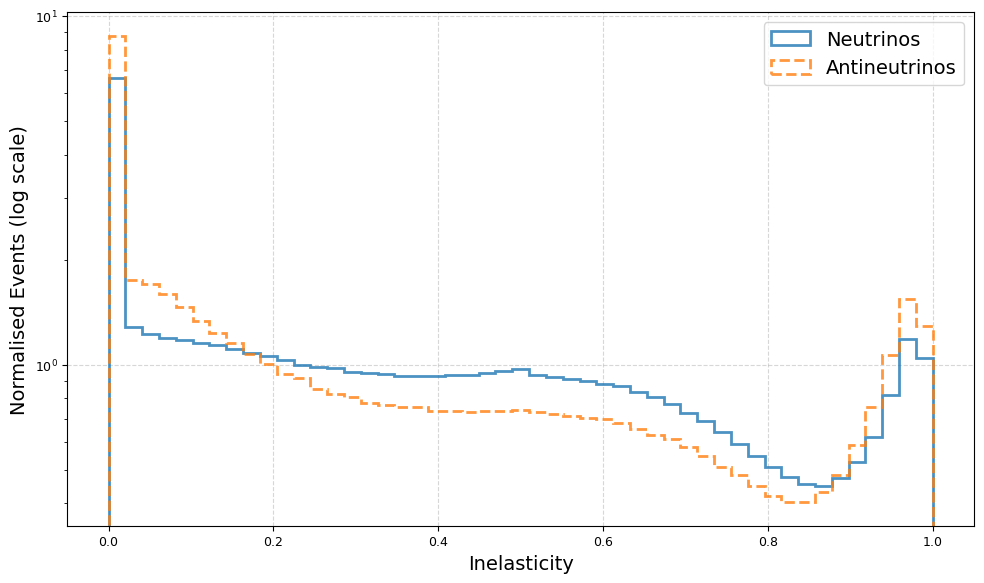

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

neutrinos = data[data['label'] == 0]
antineutrinos = data[data['label'] == 1]

def set_plot_style():
	plt.rcParams.update({
		"font.size": 12,
		"axes.labelsize": 14,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 14,
		"lines.linewidth": 1.5
	})
	
set_plot_style()

all_neutrinos = pd.concat([neutrinos['inelasticity_e'], neutrinos['inelasticity_mu']])
all_antineutrinos = pd.concat([antineutrinos['inelasticity_e'], antineutrinos['inelasticity_mu']])

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(0, 1, 50)

ax.hist(all_neutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, label='Neutrinos')
ax.hist(all_antineutrinos, bins=bins, alpha=0.8, density=True, histtype='step', linewidth=2, linestyle='--', label='Antineutrinos')

ax.set_yscale('log')
ax.grid(True, alpha=0.5, linestyle='--')
ax.legend()
ax.set_xlabel('Inelasticity')
ax.set_ylabel('Normalised Events (log scale)')

plt.tight_layout()
fig.savefig("inelasticity_distributions_combined.pdf", bbox_inches='tight')
plt.show()

In [3]:
# code to set only the inelasticity of the correct neutrino type to non zero for each event

import numpy as np

data["inelasticity"] = np.select([data["PDG"].abs() == 14,data["PDG"].abs() == 12,],[data["inelasticity_mu"],data["inelasticity_e"],],default=np.nan)

data = data.drop(columns=["inelasticity_e", "inelasticity_mu"])

data= data[data["PDG"].abs() != 16]


data


,event_index,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,label,inelasticity
0,0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,1,0.435292
1,1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,1,0.480347
2,2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,1,0.254924
3,4,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0,0.149645
5,6,0.000000e+00,0.021875,0.000000,0.122300,-12,True,2,1,0,0.010483,0,1,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,2884698,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,0,0.000000
2651023,2884699,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0,0.009781
2651024,2884700,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0,0.067633
2651025,2884701,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0,0.040787


In [4]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       1695474        0
PDG < 0 (Anti-Nu)        0   547148


In [6]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]
data_pfp_1 = data[data["n_reco_pfps"] > 1]
# data_E_10gev = data_pfp_1[data_pfp_1["E"] > 10]

In [7]:
data_type = data_pfp_1


feature_columns = ['inelasticity', 'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']
data = data_type.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = data[feature_columns].values


y_data = data['label'].values

data[feature_columns]

,inelasticity,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
0,0.564708,10,5,4,11.487990,4,1
1,0.519653,2,1,0,0.110940,1,0
2,0.745076,4,3,0,0.064570,2,1
3,0.850355,3,2,0,0.002420,1,1
5,1.000000,2,1,0,0.010483,0,1
...,...,...,...,...,...,...,...
2651022,1.000000,2,1,0,0.000000,1,0
2651023,0.990219,2,1,0,0.005397,1,0
2651024,0.932367,3,1,1,0.012165,1,0
2651025,0.959213,3,1,1,0.102556,0,1


In [8]:
plt.plot

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

In [9]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([1695474,  547148]))


In [10]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

clf = HistGradientBoostingClassifier(
	random_state=42,
	class_weight="balanced",
	early_stopping=True
)

param_dist = {
	"learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
	"max_depth": [3, 4, 5, 6, 7, None],
	"min_samples_leaf": [5, 10, 20, 30, 50, 100],
	"max_leaf_nodes": [20, 30, 40, 50, 60, None],
	"max_iter": [200, 500, 1000, 2000],
	"l2_regularization": [0.0, 0.01, 0.1, 1.0, 10.0]
}

search = RandomizedSearchCV(
	estimator=clf,
	param_distributions=param_dist,
	n_iter=40,
	scoring="roc_auc",
	cv=5,
	n_jobs=-1,
	verbose=2,
	random_state=0
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV AUC:", search.best_score_)

best_clf = search.best_estimator_
y_score = best_clf.predict_proba(X_test)[:, 1]
print("Test AUC:", roc_auc_score(y_test, y_score))



Fitting 5 folds for each of 40 candidates, totalling 200 fits


[CV] END l2_regularization=0.1, learning_rate=0.2, max_depth=None, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  40.5s
[CV] END l2_regularization=0.1, learning_rate=0.2, max_depth=None, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  41.2s
[CV] END l2_regularization=0.1, learning_rate=0.2, max_depth=None, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  43.6s
[CV] END l2_regularization=1.0, learning_rate=0.15, max_depth=7, max_iter=500, max_leaf_nodes=60, min_samples_leaf=50; total time=  46.4s
[CV] END l2_regularization=0.1, learning_rate=0.2, max_depth=None, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  46.9s
[CV] END l2_regularization=0.1, learning_rate=0.2, max_depth=None, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  48.4s
[CV] END l2_regularization=1.0, learning_rate=0.15, max_depth=7, max_iter=500, max_leaf_nodes=60, min_samples_leaf=50; total time=  49.6s
[CV] END l2_regularizati

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0      131.756110     16.637915         9.833179        0.926202   
1      306.172741     17.743354        22.807142        2.965336   
2       56.903344      9.522042         4.447445        0.684639   
3       54.071742      8.819191         3.546019        0.641677   
4       92.643101      3.692887         7.078085        0.534935   
5      265.229675      5.100215        16.174509        0.135114   
6       62.220338     10.902639         4.283477        0.913016   
7       95.789773     11.738363         8.193076        1.140991   
8       87.780726      1.677063         6.793657        0.649249   
9      191.633897      8.909293         8.828878        0.912079   
10      76.990335      6.236947         5.726402        0.458276   
11      53.719856      4.232377         4.349908        0.610644   
12      41.729275      3.014831         2.401716        0.183240   
13     315.156907     14.929035        24.599463

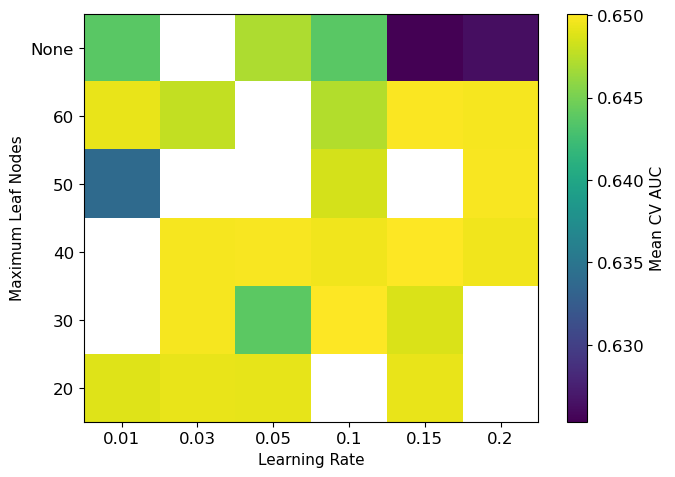

param_learning_rate,0.01,0.03,0.05,0.10,0.15,0.20
param_max_leaf_nodes_plot,,,,,,
20,0.648876,0.649296,0.649205,NaN,0.649294,NaN
30,NaN,0.649739,0.643881,0.650086,0.648675,NaN
40,NaN,0.649715,0.649863,0.649515,0.650007,0.649565
50,0.633875,NaN,NaN,0.648539,NaN,0.649882
60,0.649229,0.647783,NaN,0.647282,0.649929,0.649750
None,0.643788,NaN,0.647057,0.643731,0.625346,0.626292


In [49]:
results = pd.DataFrame(search.cv_results_)

print(results)

results["param_max_leaf_nodes_plot"] = results["param_max_leaf_nodes"].apply(
	lambda x: "None" if x is None else str(x)
)

heatmap_df = results.pivot_table(
	index="param_max_leaf_nodes_plot",
	columns="param_learning_rate",
	values="mean_test_score",
	aggfunc="mean"
)

def set_plot_style():
	plt.rcParams.update({
		"font.size": 14,
		"axes.labelsize": 11,
		"xtick.labelsize": 12,
		"ytick.labelsize": 12,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

depth_order = [str(x) for x in [20, 30, 40, 50, 60] + ["None"]]
heatmap_df = heatmap_df.reindex([d for d in depth_order if d in heatmap_df.index])

plt.figure(figsize=(7, 5))
im = plt.imshow(heatmap_df, aspect="auto", origin="lower")
plt.colorbar(im, label="Mean CV AUC")

plt.xticks(
	ticks=np.arange(len(heatmap_df.columns)),
	labels=heatmap_df.columns
)
plt.yticks(
	ticks=np.arange(len(heatmap_df.index)),
	labels=heatmap_df.index
)

plt.ylabel("Maximum Leaf Nodes")
plt.xlabel("Learning Rate")
plt.tight_layout()
plt.savefig("heatmap.pdf")
plt.show()

heatmap_df

In [ ]:
breakpoint()

In [31]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.01,
    l2_regularization=0.01,
	max_depth=None,
    max_leaf_nodes=60,
	min_samples_leaf=5,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0,
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [32]:
scores_train = clf.decision_function(X_train)

scores_test = clf.decision_function(X_test)

In [33]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([559342, 180724]))


834


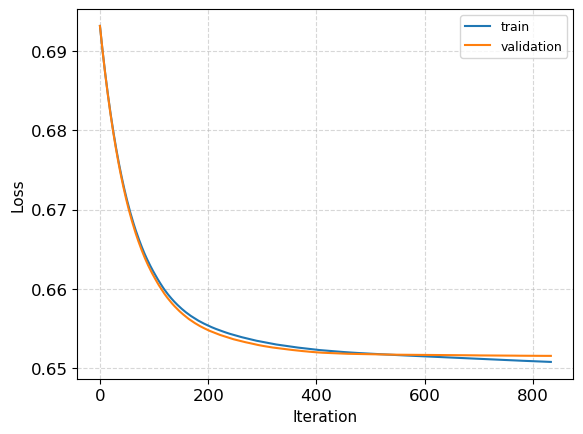

In [34]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

print(len(train_loss))

def set_plot_style():
	plt.rcParams.update({
		"font.size": 10,
		"axes.labelsize": 11,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.5, linestyle="--")
plt.legend()
plt.savefig("training_validation_loss.pdf")
plt.show()


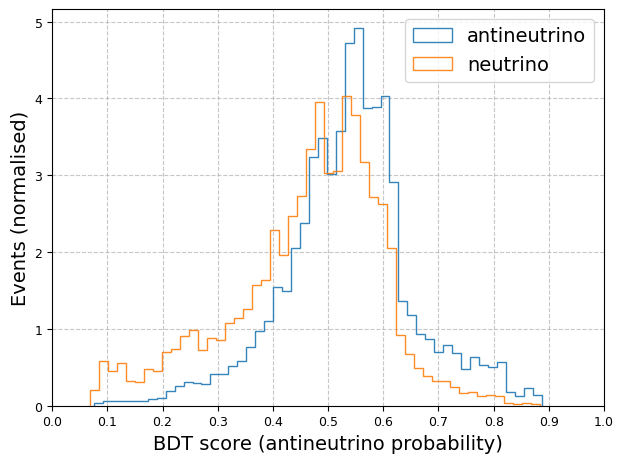

[0.38456037 0.41389299 0.56059796 ... 0.71277973 0.58447021 0.12750772]


In [17]:

def set_plot_style():
	plt.rcParams.update({
		"font.size": 10,
		"axes.labelsize": 11,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})


score = clf.predict_proba(X_test)[:,1]


plt.hist(score[y_test==1], bins=50, alpha=0.9, label="antineutrino", density = True,  histtype="step")
plt.hist(score[y_test==0], bins=50, alpha=0.9, label="neutrino", density = True, histtype="step")

plt.xlabel("BDT score (antineutrino probability)")
plt.xticks(np.arange(0, 1.1, 0.1))
plt.ylabel("Events (normalised)")
plt.legend()
plt.tight_layout()
plt.grid(linestyle="--", alpha=0.7)
plt.savefig("bdt_score_histogram.pdf")
plt.show()

print(score)

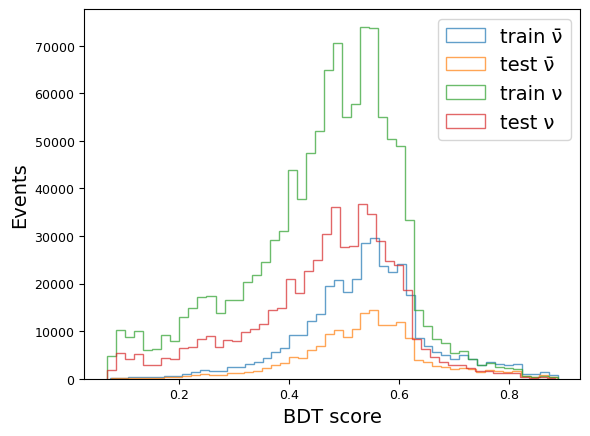

In [18]:
score_train = clf.predict_proba(X_train)[:,1]
score_test  = clf.predict_proba(X_test)[:,1]

plt.hist(score_train[y_train==1], bins=50, alpha=0.7, label="train ν̄",histtype = 'step')
plt.hist(score_test[y_test==1],  bins=50, alpha=0.7, label="test ν̄", histtype = 'step')

plt.hist(score_train[y_train==0], bins=50, alpha=0.7, label="train ν", histtype = 'step')
plt.hist(score_test[y_test==0],  bins=50, alpha=0.7, label="test ν", histtype = 'step')

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()
plt.show()



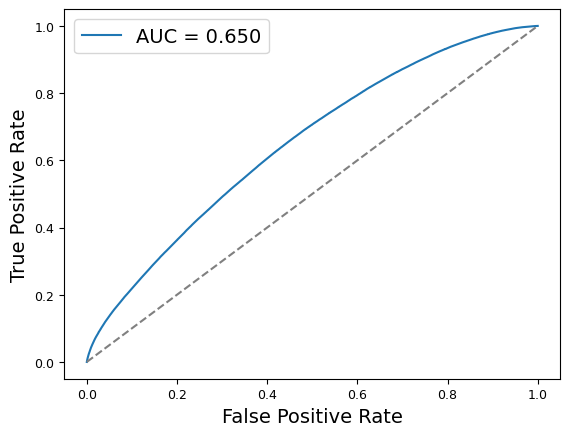

In [19]:
from sklearn.metrics import roc_curve, auc

def set_plot_style():
	plt.rcParams.update({
		"font.size": 10,
		"axes.labelsize": 11,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("roc_curve.pdf")
plt.show()


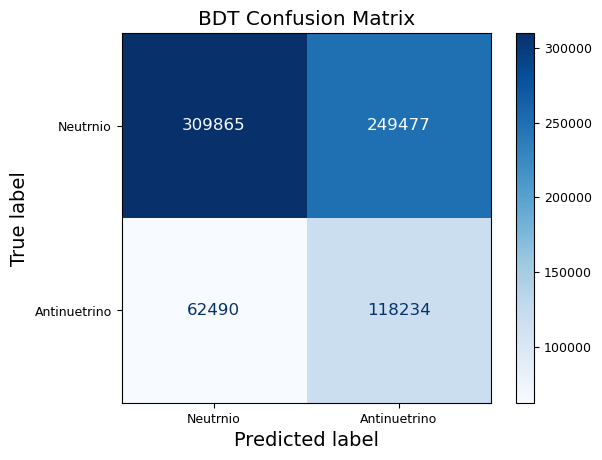

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def set_plot_style():
	plt.rcParams.update({
		"font.size": 10,
		"axes.labelsize": 11,
		"xtick.labelsize": 9,
		"ytick.labelsize": 9,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [21]:
# from sklearn.inspection import permutation_importance
# r = permutation_importance(clf, X_data, y_data, n_repeats=5)


In [22]:
label_map = {
    "Enu_e_had": "Hadronic Energy (e)",
    "Enu_e_calo": "Calorimetric Energy (e)",
    "Enu_mu_had": "Hadronic Energy (μ)",
    "Enu_mu_range": "Range-based Energy (μ)",
    "PDG": "True PDG Code",
    "n_reco_pfps": "Number of Daughter Particles",
    "n_reco_tracks": "Number of Tracks",
    "n_reco_showers": "Number of Showers",
    "n_reco_muons_pions": "Number of Muons/Pions",
    "n_reco_protons": "Number of Protons",
    "single_hits_energy": "Single Hits Energy",
    "n_true_nu": "N True Neutrinos",
    "n_primary_daughters": "N Primary Daughters",
    "n_primary_electrons": "N Primary Electrons",
    "n_primary_muons": "N Primary Muons",
    "n_primary_protons": "N Primary Protons",
    "n_primary_pions": "N Primary Pions",
    "n_primary_photons": "N Primary Photons",
    "n_primary_pi0s": "N Primary π⁰s",
    "n_primary_tracks": "N Primary Tracks",
    "n_primary_showers": "N Primary Showers",
    "inelasticity_e": "Inelasticity (e)",
    "inelasticity_mu": "Inelasticity (μ)",
    "inelasticity": "Inelasticity",
}

def set_plot_style():
	plt.rcParams.update({
		"font.size": 14,
		"axes.labelsize": 11,
		"xtick.labelsize": 12,
		"ytick.labelsize": 12,
		"legend.fontsize": 9,
		"axes.titlesize": 11,
		"lines.linewidth": 1.5
	})

set_plot_style()

means = r["importances_mean"]
stds = r["importances_std"]
sorted_idx = np.argsort(means)

labels = [label_map.get(feature_columns[i], feature_columns[i]) for i in sorted_idx]

plt.figure(figsize=(8, 6))
plt.grid(axis="x", linestyle="--", alpha=1)
plt.barh(
	labels,
	means[sorted_idx],
	# xerr=stds[sorted_idx],
	# capsize=20,
	# error_kw={"elinewidth": 5}
)
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.savefig("feature_importance.pdf")
plt.show()

NameError: name 'r' is not defined

In [ ]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.6540641461348884


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.83      0.55      0.67    559342
Antineutrino       0.32      0.65      0.43    180724

    accuracy                           0.58    740066
   macro avg       0.58      0.60      0.55    740066
weighted avg       0.71      0.58      0.61    740066



740066
2242622
740065.26


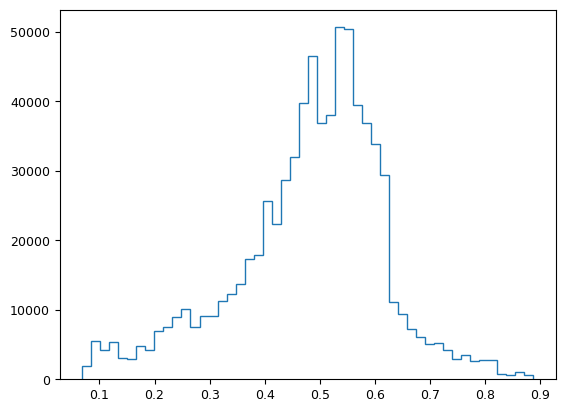

In [ ]:
plt.hist(score, histtype="step", bins=50, label="test" )
print(len(score))
print(len(y_data))
print(0.33*len(y_data))

In [ ]:
hard_predictions = clf.predict(X_data)
probs = clf.predict_proba(X_data)
decision_scores = clf.decision_function(X_data)


results_df = pd.DataFrame({
    'true_label': y_data,
    'predicted_label': hard_predictions,
    'prob_neutrino': probs[:, 0],
    'prob_antineutrino': probs[:, 1],
    'decision_score': decision_scores
})



print(results_df.head())

   true_label  predicted_label  prob_neutrino  prob_antineutrino  \
0           1                1       0.416256           0.583744   
1           1                1       0.428662           0.571338   
2           1                0       0.587576           0.412424   
3           0                0       0.909712           0.090288   
4           1                1       0.392953           0.607047   

   decision_score  
0        0.338162  
1        0.287314  
2       -0.353952  
3       -2.310122  
4        0.434916  


In [ ]:
score_column = results_df['prob_antineutrino']

In [ ]:
all_probs = clf.predict_proba(X_data)[:, 1]

final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': all_probs
})

final_output.to_csv("bdt_scores_with_index.csv", index=False)

In [ ]:
final_output

,event_index,bdt_score
0,0,0.583744
1,1,0.571338
2,2,0.412424
3,4,0.090288
5,6,0.607047
...,...,...
2651022,2884698,0.517500
2651023,2884699,0.481686
2651024,2884700,0.433600
2651025,2884701,0.523308


In [ ]:
fpr, tpr, thresholds = roc_curve(y_data, all_probs)
j_scores = tpr - fpr
# best_threshold = thresholds[np.argmax(j_scores)]
best_threshold = thresholds[np.argmin(np.abs(tpr - (1 - fpr)))]
print(best_threshold)

0.517053382417148


In [ ]:
all_probs = clf.predict_proba(X_data)[:, 1]


final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': np.random.uniform(0, 1, len(all_probs))
})


final_output.to_csv("randomised_bdt_scores_with_index.csv", index=False)